# DAC Latent Viewer
Load and inspect `.pt` files containing DAC (Descript Audio Codec) latent representations.

**Features**:
- Load latents by file path or index
- View metadata (sample rate, duration, tensor shapes)
- Visualize codebook indices over time
- Plot latent distributions and time series

## Import Libraries

In [1]:
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt

## Scan for .pt Files
Set base directory and find all DAC latent files.

In [3]:
# Set base directory containing .pt files
base_dir = Path(r"C:\Users\Dhanuja\Desktop\Vibeshift\VibeShift\data\output").resolve()

pt_files = sorted(base_dir.rglob("*.pt"))
print(f"Found {len(pt_files)} .pt files under {base_dir}")

Found 2112 .pt files under C:\Users\Dhanuja\Desktop\Vibeshift\VibeShift\data\output


In [ ]:
# List first 50 files with indices
for i, p in enumerate(pt_files[:50]):
    print(f"{i:03d}: {p.name}")
if len(pt_files) > 50:
    print(f"... and {len(pt_files) - 50} more files")

## Load a DAC Latent File
Choose a file by index or provide a direct path.

In [4]:
# Option 1: Select by index
index = 0

# Option 2: Or provide direct path (uncomment and edit)
pt_path = Path(r"C:\Users\Dhanuja\Desktop\Vibeshift\VibeShift\data\output\00000_Preludes Book 2 -.pt")

# Load the file
if 'pt_path' not in locals():
    if len(pt_files) == 0:
        raise FileNotFoundError("No .pt files found. Check base_dir.")
    pt_path = pt_files[index]

data = torch.load(pt_path, map_location="cpu")

# Display file info
print(f"✓ Loaded: {pt_path.name}")
print(f"  Path: {pt_path}")
print(f"  Size: {pt_path.stat().st_size / 1024:.1f} KB")
print(f"  Type: {type(data).__name__}")

if isinstance(data, dict):
    print(f"  Keys: {list(data.keys())}")
else:
    print(f"  ⚠ Warning: Expected dict, got {type(data)}")

✓ Loaded: 00000_Preludes Book 2 -.pt
  Path: C:\Users\Dhanuja\Desktop\Vibeshift\VibeShift\data\output\00000_Preludes Book 2 -.pt
  Size: 11251.1 KB
  Type: dict
  Keys: ['z', 'codes', 'latents', 'sample_rate', 'original_length']


## View Metadata and Tensor Features
Display audio metadata and detailed tensor information.

In [5]:
if not isinstance(data, dict):
    print("⚠ Not a dictionary. Cannot inspect DAC latent structure.")
else:
    print("\n" + "="*50)
    print("AUDIO METADATA")
    print("="*50)
    
    # Show audio metadata
    if 'sample_rate' in data:
        print(f"Sample Rate:     {data['sample_rate']:,} Hz")
    if 'original_length' in data:
        print(f"Original Length: {data['original_length']:,} samples")
        if 'sample_rate' in data:
            duration = data['original_length'] / data['sample_rate']
            print(f"Duration:        {duration:.2f} seconds ({duration/60:.2f} minutes)")
    
    print("\n" + "="*50)
    print("TENSOR FEATURES")
    print("="*50)
    
    # Display each tensor
    for key in ['z', 'codes', 'latents']:
        if key in data and torch.is_tensor(data[key]):
            t = data[key]
            print(f"\n[{key.upper()}]")
            print(f"  Shape:       {tuple(t.shape)}")
            print(f"  Dtype:       {t.dtype}")
            print(f"  Device:      {t.device}")
            print(f"  Memory:      {t.element_size() * t.numel() / 1024:.1f} KB")
            
            if t.numel() > 0:
                t_np = t.detach().cpu().numpy()
                print(f"  Value Range: [{t_np.min():.4f}, {t_np.max():.4f}]")
                print(f"  Mean:        {t_np.mean():.4f}")
                print(f"  Std Dev:     {t_np.std():.4f}")


AUDIO METADATA
Sample Rate:     44,100 Hz
Original Length: 1,323,119 samples
Duration:        30.00 seconds (0.50 minutes)

TENSOR FEATURES

[Z]
  Shape:       (1, 1024, 2585)
  Dtype:       torch.float32
  Device:      cpu
  Memory:      10340.0 KB
  Value Range: [-17.1311, 20.7401]
  Mean:        0.0393
  Std Dev:     3.5670

[CODES]
  Shape:       (1, 9, 2585)
  Dtype:       torch.int64
  Device:      cpu
  Memory:      181.8 KB
  Value Range: [0.0000, 1023.0000]
  Mean:        505.6425
  Std Dev:     295.7908

[LATENTS]
  Shape:       (1, 72, 2585)
  Dtype:       torch.float32
  Device:      cpu
  Memory:      727.0 KB
  Value Range: [-16.5045, 15.0597]
  Mean:        0.0418
  Std Dev:     3.0635


## Visualize Codebook Indices
Heatmap showing discrete codebook indices over time.

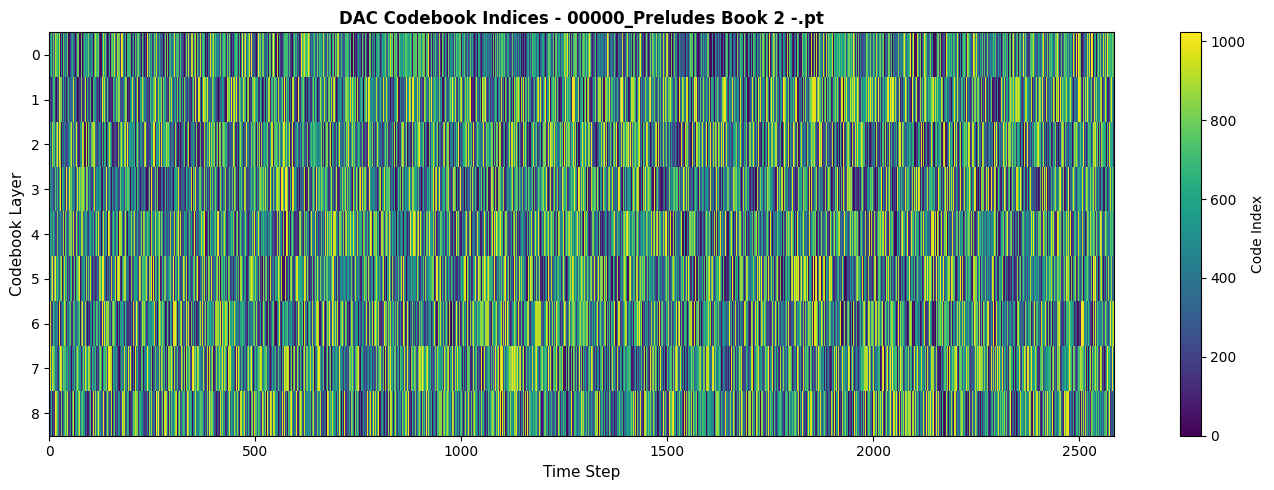

✓ Codes shape: (9, 2585)
  • Number of codebook layers: 9
  • Time steps: 2585
  • Unique codes per layer: [272, 705, 890]


In [6]:
if 'codes' in data and torch.is_tensor(data['codes']):
    codes = data['codes'].cpu().numpy()
    
    if codes.ndim == 3:
        batch_idx = 0
        codes_2d = codes[batch_idx]  # (num_codebooks, time)
        
        fig, ax = plt.subplots(figsize=(14, 5))
        im = ax.imshow(codes_2d, aspect='auto', cmap='viridis', interpolation='nearest')
        ax.set_xlabel('Time Step', fontsize=11)
        ax.set_ylabel('Codebook Layer', fontsize=11)
        ax.set_title(f'DAC Codebook Indices - {pt_path.name}', fontsize=12, fontweight='bold')
        
        cbar = plt.colorbar(im, ax=ax, label='Code Index')
        plt.tight_layout()
        plt.show()
        
        print(f"✓ Codes shape: {codes_2d.shape}")
        print(f"  • Number of codebook layers: {codes_2d.shape[0]}")
        print(f"  • Time steps: {codes_2d.shape[1]}")
        print(f"  • Unique codes per layer: {[len(np.unique(codes_2d[i])) for i in range(min(3, codes_2d.shape[0]))]}")
    else:
        print(f"⚠ Unexpected codes shape: {codes.shape}")
else:
    print("⚠ No 'codes' tensor found in data.")

## Visualize Quantized Latents
Distribution and time series plots for the 'z' tensor.

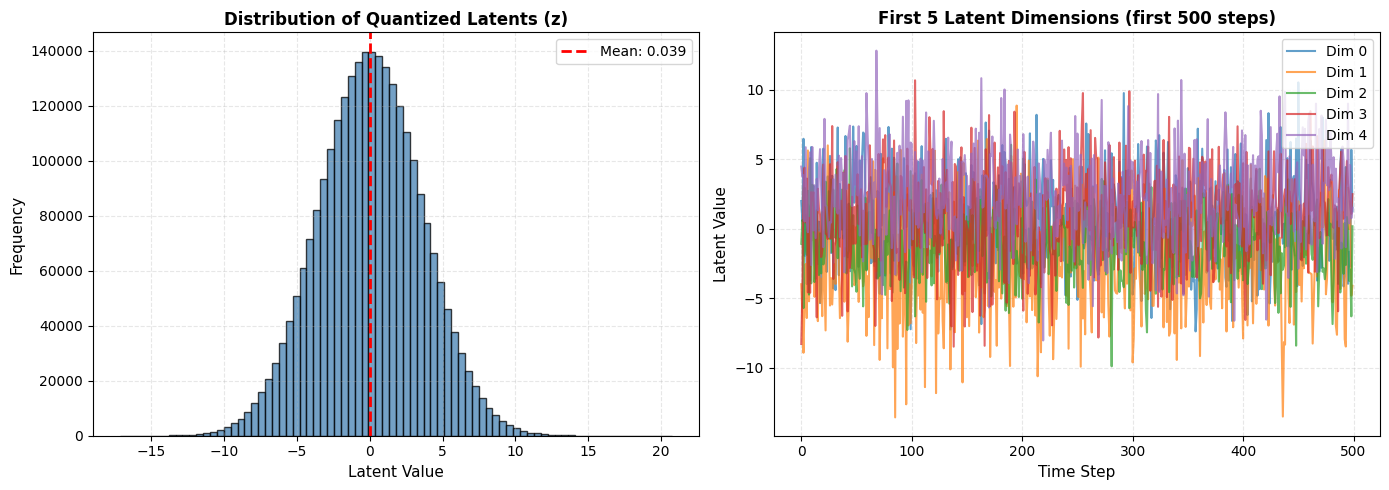

✓ Latent 'z' statistics:
  • Total elements: 2,647,040
  • Range: [-17.1311, 20.7401]
  • Mean: 0.0393, Median: 0.0404
  • Std: 3.5670


In [7]:
if 'z' in data and torch.is_tensor(data['z']):
    z = data['z'].cpu().numpy()
    z_flat = z.ravel()
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left: Histogram
    ax1.hist(z_flat, bins=80, edgecolor='black', alpha=0.75, color='steelblue')
    ax1.set_xlabel('Latent Value', fontsize=11)
    ax1.set_ylabel('Frequency', fontsize=11)
    ax1.set_title('Distribution of Quantized Latents (z)', fontsize=12, fontweight='bold')
    ax1.grid(alpha=0.3, linestyle='--')
    ax1.axvline(z_flat.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {z_flat.mean():.3f}')
    ax1.legend()
    
    # Right: Time series of first few dimensions
    if z.ndim == 3:  # (batch, latent_dim, time)
        batch_idx = 0
        z_2d = z[batch_idx]  # (latent_dim, time)
        num_dims_to_plot = min(5, z_2d.shape[0])
        max_time_steps = min(500, z_2d.shape[1])
        
        for i in range(num_dims_to_plot):
            ax2.plot(z_2d[i, :max_time_steps], alpha=0.7, linewidth=1.5, label=f'Dim {i}')
        
        ax2.set_xlabel('Time Step', fontsize=11)
        ax2.set_ylabel('Latent Value', fontsize=11)
        ax2.set_title(f'First {num_dims_to_plot} Latent Dimensions (first {max_time_steps} steps)', 
                     fontsize=12, fontweight='bold')
        ax2.legend(loc='upper right')
        ax2.grid(alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.show()
    
    print(f"✓ Latent 'z' statistics:")
    print(f"  • Total elements: {z.size:,}")
    print(f"  • Range: [{z_flat.min():.4f}, {z_flat.max():.4f}]")
    print(f"  • Mean: {z_flat.mean():.4f}, Median: {np.median(z_flat):.4f}")
    print(f"  • Std: {z_flat.std():.4f}")
else:
    print("⚠ No 'z' tensor found in data.")

## Convert Back to Audio
Decode the latents back to audio using DAC.

In [8]:
import sys
import dac
from audiotools import AudioSignal
from IPython.display import Audio, display

# Load DAC model
print("Loading DAC model...")
model_path = dac.utils.download(model_type="44khz")
model = dac.DAC.load(model_path)
model.eval()
print("✓ Model loaded")

# Decode latents to audio
if 'z' in data and torch.is_tensor(data['z']):
    print("\nDecoding latents to audio...")
    with torch.no_grad():
        z = data['z']
        audio_decoded = model.decode(z)
    
    # Get sample rate
    sample_rate = data.get('sample_rate', 44100)
    
    # Convert to numpy for playback
    audio_np = audio_decoded.squeeze(0).cpu().numpy()
    
    print(f"✓ Audio reconstructed")
    print(f"  • Sample rate: {sample_rate} Hz")
    print(f"  • Shape: {audio_decoded.shape}")
    print(f"  • Duration: {audio_np.shape[-1] / sample_rate:.2f} seconds")
    
    # Display audio player
    print("\n🔊 Playing audio:")
    display(Audio(audio_np, rate=sample_rate))
else:
    print("⚠ No 'z' tensor found. Cannot decode to audio.")

Loading DAC model...


c:\Users\Dhanuja\Desktop\Vibeshift\VibeShift\.venv\lib\site-packages\torch\nn\utils\weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


✓ Model loaded

Decoding latents to audio...
✓ Audio reconstructed
  • Sample rate: 44100 Hz
  • Shape: torch.Size([1, 1, 1323520])
  • Duration: 30.01 seconds

🔊 Playing audio:
